# Distributions, Normal Distribution, $z$-Scores and the Law of Large Numbers

## 1. Retrieval

1. What does the expected value of a random variable represent?

> The probability-weighted mean of a random variable

2. What does the variance of a random variable describe?

> The expected squared difference from the mean: $$Var(X)=E[(X-E[X])^2]$$ 

3. What is the difference between a discrete random variable and a continuous random variable?

> A discrete random variable takes separate, countable values, while a continuous random variable can take any value within a range

4. Suppose a random variable $X$ has: $$ E[X]=10 $$ and: $$ Var(X)=9 $$ What is its standard deviation?

> $\sigma=\sqrt{Var(X)}=\sqrt{9}=3$
>
> Because the deviations are squared, variance is expressed in squared units. The standard deviation brings this back to the original units and is often more intuitive as a measure of typical spread

5. In the Bayes simulation from the previous session, why did the simulated prevalence not equal exactly $0.01$, even though we generated each person using: `infected = rng.random(n) < 0.01`

> `rng.random(n)` generates n random numbers between 0-1. These are then compared to the prevalence 0.01, and if they are below this value then the person is set as infected. The reason the simulated prevalence doesn't come out as exactly 0.01 is because the simulation is only run for 100,000 tested people; as the sample size becomes very large, the sample proportion tends to converge towards the unerlying probability.

## 2. Probability distributions and the normal distribution

Watch this [StatQuest normal-distribution video](https://www.youtube.com/watch?v=rzFX5NWojp0) and answer:

1. What is a probability distribution trying to describe?

> A probability distribution describes how probability is distributed across the possible values or ranges of values of a random variable

2. For a normal distribution, what do the parameters $\mu$ and $\sigma$ control?

> $\mu$ is the average, and it controls the position of the center of the curve
>
> $\sigma$ is the standard deviation, and it contorls the width (and therefore also the height) of the curve

3. Suppose two normal distributions have the same $\mu$ but different $\sigma$. What would look different about their shapes?

> They would be centered on the same value but one would be taller and less wide, while the curve with the larger $\sigma$ wil be wider and less tall

4. Suppose instead they have the same $\sigma$ but different $\mu$. What would change?

> The curves will have the same shape but they will be centered on different points

## 3. Standardisation and $z$-scores

Suppose exam scores are approximately normally distributed with: $$\mu=70,\qquad\sigma=10$$

A student scores: $$x=85$$

Saying the scored 85 doesn't immediatley tell us how unusual that score is unless we know the distribution.

Instead, we can measure how far the observation is from the mean in **units of standard deviations**:

$$z=\frac{x-\mu}{\sigma}$$

The result is called a $z$-score.

Interpretations:
- $x=0$: exactly the same as the mean.
- $x=1$: one standard deviation abone the mean.
- $x=-2$: two standard deviations below the mean.
- larger $\lvert z\rvert$: further from the mean relative to the distribution's spread.

### Exercise 1 — calculate and interpre

For the exam distribution: $$\mu=70,\qquad\sigma=10$$

calculate the $z$-score for: $$x=85$$

> $z=\frac{x-\mu}{\sigma}$
>
> $z=\frac{85-70}{10}=1.5$

Then answer in words:
1. What does the sign of your $z$-score tell you?

> Whether the value of X is higher (positive z) or lower (negaitve z) than the average

2. What does its magnitude tell you?

> How many standard deviation units the score is from the mean

### Exercise 2 — comparing different scales

Now suppose:
- Alice scores 85 on an exam with $\mu=70$, $\sigma=10$.
- Ben scores 720 on another exam with $\mu=600$, $\sigma=100$.

> - Alice: $z=\frac{85-70}{10}=1.5$
> - Ben: $z=\frac{720-600}{100}=1.2$
>
> Relative to the other students, Alice performed better because their score was more standard deviation units form the mean than Ben's score

## 4. Law of Large Numbers

If we repeatedly sample from the same distribution, the sample average tends to move toward the true expected value as the sample size grows.

Suppose we simulate fair six-sided dice. The expected value is: $$E[X]=\frac{1+2+3+4+5+6}{6}=3.5$$

But if you roll the dice only a few times, the sample mean might be nowhere near $3.5$.

For example:
```
rolls = [6, 6, 5]
```
has a sample mean of: $$\frac{17}{3}\approx 5.67$$

That doesn't contradict the expected value. It's just a small random sample.

As $n$ becomes large, though, we'd expect: $$\bar{X}_n\rarr E[X]$$

where $\bar{X}_n$ is the sample mean after $n$ observations.

One important caveat. this does **not** mean the sample mean must get closer after every additional observation. It can wiggle around. The claim is about its long-run behaviour.

### NumPy exercise

Use:

In [55]:
import numpy as np

rng = np.random.default_rng(42)

n = 10_000
rolls = rng.integers(1, 7, size=n)

First answer these before witing the rest of the code:
1. What shape will `rolls` have?

> (n,)

2. Roughly what would you expect `rolls.mean()` to be?

> Approximatley 3.5, since this is the expected result and for a simulation that uses 10,000 rolls the sample average should be close to the expected value 

3. Why do we use `7` as the upper argument to rng.integers() when a die only goes up to 6?

> The high argument of rng.integers() defines one above the largest integer to be drawn from the distribution, therefore rng.integers(1, 7, size=n) draws n integers between 1-6

## 5. Running mean

Now we want to see how the sample mean evolves as more rolls are included.

For rolls: $$x_1,x_2,...,x_n$$

the running mean after the first $k$ roll is: $$\bar{x}_k=\frac{x_1+x_2+...+x_k}{k}$$

So we need two arrays:
- cumulative total after each roll
- number of rolls included at each point

NumPy has:
```
np.cumsum(rolls)
```
which gives something conceptually like:
```
rolls:        [4,  2,  6,  3, ...]
cumulative:   [4,  6,  12,  15, ...]
```

### Your task
Create a vectorised `running_mean` array with shape `(1000,)`.

Don't use a Python loop.

Once you've got running_mean, print:

```
running_mean[0]
running_mean[9]
running_mean[99]
running_mean[999]
running_mean[-1]
```

These represent the sample means after 1, 10, 100, 1,000 and 10,000 rolls.

In [56]:
cumulative_sum = np.cumsum(rolls)
roll_number = np.arange(1, n + 1)
running_mean = cumulative_sum / roll_number

print('Sample mean after 1 roll:',running_mean[0])
print('Sample mean after 10 roll:',running_mean[9])
print('Sample mean after 100 roll:',running_mean[99])
print('Sample mean after 1000 roll:',running_mean[999])
print('Sample mean after 10000 roll:',running_mean[-1])

Sample mean after 1 roll: 1.0
Sample mean after 10 roll: 3.1
Sample mean after 100 roll: 3.64
Sample mean after 1000 roll: 3.488
Sample mean after 10000 roll: 3.4752


## 6. Plot the convergence

Make a plot of the running mean and include a horisontal reference line at: $$y=3.5$$

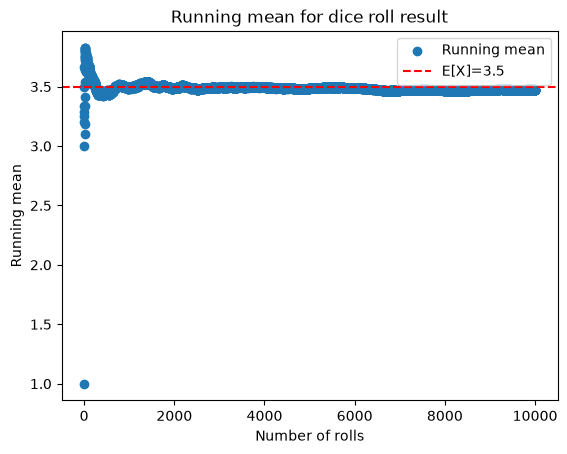

In [57]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.scatter(roll_number, running_mean, label='Running mean')
plt.axhline(y = 3.5, color='red', linestyle='--', label='E[X]=3.5')
ax.set_title('Running mean for dice roll result')
ax.set_xlabel('Number of rolls')
ax.set_ylabel('Running mean')
ax.legend()


Plot shows that for low numbers of rolls there is the highest difference between the running mean and the expected result, as as the number of rolls increases there is less and less 'wiggle' as the mean tends closer to 3.5, however even after 10,000 rolls there is still some amount of 'wiggle' as the fluctuations have not comepletey stopped.